<img src="ost_logo.png" width="240"  align="right"/>
<div style="text-align: left"> <b> Machine Learning </b> <br> MSE FTP MachLe <br> 
<a href="mailto:christoph.wuersch@ost.ch"> Christoph Würsch </a> </div>

# Lab11: A4 Image Compression using `kMeans`

Clustering can be used to reduce colors in an image. Similar colors will be assigned to the same
cluster label or color palette. In In the following exercise, you will load an image as a $\left[ w, h, 3\right]$
`numpy.array` of type float64 , where $w$ and $h$ are the width and height in pixels respecively.
The last dimension of the three dimensional array are three the RGB color channels. Using
kMeans, we will reduce the color depth from 24 bits to 64 colors (6 bits) and to 16 colors (4
bits).

### (a) Reading an Image

Start by reading in an image from the Python imaging library PIL (https://en.wikipedia.org/wiki/Python_Imaging_Library) in your Jupyter notebook.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.utils import shuffle
from PIL import Image

# First we read and flatten the image. 
original_img = np.array(Image.open('./images/Hirsch.jpg'), dtype=np.float64) / 255
print(original_img.shape)
original_dimensions = tuple(original_img.shape)
width, height, depth = tuple(original_img.shape)


(1960, 4032, 3)


### (b) Flatten the image

Flatten the image to a $\left[w \cdot h, 3 \right]$-dimensional numpy.array and shuffle the pixels using
sklearn.utils.shuffle.

In [4]:
image_flattened = np.reshape(original_img, (width * height, depth))

### (c) Quantization to 64 colors

Create an instance of the `kMeans` class called estimator. Use the `fit` method of `kMeans` to create sixty-four clusters (`n_clusters=64`) from a sample of one thousand randomly selected colors, e.g. the first 1000 colors of the shuffled pixels. The new color palette is given by the cluster centers that are accessible in `estimator.cluster_centers_`.
Each of the clusters will be a color in the compressed palette.

In [5]:
image_array_sample = shuffle(image_flattened, random_state=0)[:1000]
estimator = KMeans(n_clusters=8, random_state=0)
estimator.fit(image_array_sample)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",8
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


### (d) Prediction of the cluster assignment (labels)

Assign the cluster labels to each pixel in the original image using the `.predict` method
of your `kMeans` instance. Now, you know to which color in your reduced palette each pixel
belongs to, i.e. we predict the cluster assignment for each of the pixels in the original image.

In [6]:
cluster_assignments = estimator.predict(image_flattened)

### (e) Create a compressed image using only 64 colors

Finally, we create the compressed image from the compressed palette and cluster assignments. 

Loop over all pixels and assign the new color palette corresponding to the label of the
pixel and create a new, reduced color picture. Plot the images using plt.imshow, compare
the original image and the 64 color image. Try the same with 32 and 16 colors.


In [7]:
compressed_palette = estimator.cluster_centers_
compressed_img = np.zeros((width, height, compressed_palette.shape[1]))
label_idx = 0
for i in range(width):
    for j in range(height):
        compressed_img[i][j] = compressed_palette[cluster_assignments[label_idx]]
        label_idx += 1



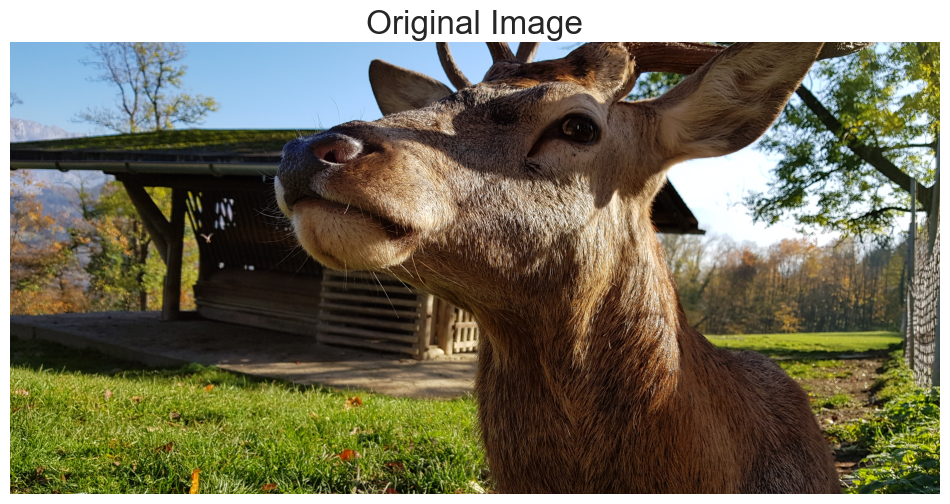

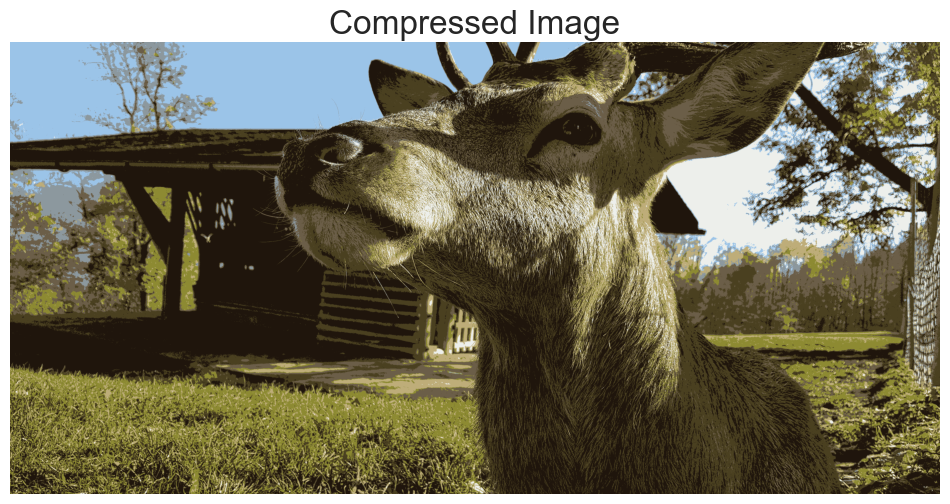

In [8]:
plt.figure(figsize=(12,12))
#plt.subplot(121)
plt.title('Original Image', fontsize=24)
plt.imshow(original_img, origin='lower')
plt.axis('off')
#plt.subplot(122)
plt.figure(figsize=(12,12))
plt.title('Compressed Image', fontsize=24)
plt.imshow(compressed_img,origin='lower')
plt.axis('off')
plt.show()

In [9]:
2**24/8

2097152.0